# Passive Flow Tracker (S&P 500)

This notebook implements an MVP for estimating ETF-driven passive flows into the S&P 500 using public market data from `yfinance`.

## MVP scope

- Define a passive ETF universe
- Download price, volume, shares outstanding, and AUM proxies
- Estimate daily ETF flows primarily from `Flow ≈ ΔShares × Price`, with AUM proxies retained for ownership and pressure context
- Aggregate flows into a passive-flow signal
- Compare the signal against `^GSPC` and derive simple regime labels

## Important assumptions

- The flow signal is based on changes in ETF shares outstanding, which is the closest public proxy for creations and redemptions. When `yfinance` share-history coverage is sparse, the flow series can be stepwise or partially unavailable.
- `yfinance` does not provide a full historical AUM series for each ETF, so this notebook estimates AUM from shares outstanding when available and otherwise falls back to a rolling 252-day volume proxy: `close × average(volume)`. That fallback has a warm-up period before values become available.
- UCITS lines can trade in non-USD currencies, so the notebook normalises to USD with daily FX rates when needed.
- The passive-pressure metric uses a configurable S&P 500 market-cap assumption for comparability rather than a fully sourced historical market-cap series.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

ARTIFACT_DIR = Path("../artifacts/passive_flow_tracker")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

START_DATE = "2018-01-01"
END_DATE = None
SP500_MARKET_CAP_USD = 45_000_000_000_000  # Adjustable modelling assumption for pressure/share metrics.
FLOW_SMOOTHING_DAYS = 5

## 1. ETF universe

The universe mixes core US listings with a few secondary and UCITS listings so the notebook can capture both domestic and cross-border passive exposure.

In [2]:
etf_universe = pd.DataFrame(

    [

        {"ticker": "SPY", "name": "SPDR S&P 500 ETF Trust", "region": "US", "distribution": "Distributing", "currency": "USD", "priority": "Core"},

        {"ticker": "VOO", "name": "Vanguard S&P 500 ETF", "region": "US", "distribution": "Distributing", "currency": "USD", "priority": "Core"},

        {"ticker": "IVV", "name": "iShares Core S&P 500 ETF", "region": "US", "distribution": "Distributing", "currency": "USD", "priority": "Core"},

        {"ticker": "SPLG", "name": "SPDR Portfolio S&P 500 ETF", "region": "US", "distribution": "Distributing", "currency": "USD", "priority": "Secondary"},

        {"ticker": "CSPX.L", "name": "iShares Core S&P 500 UCITS ETF", "region": "UCITS", "distribution": "Accumulating", "currency": "GBP", "priority": "Secondary"},

        {"ticker": "VUSA.L", "name": "Vanguard S&P 500 UCITS ETF", "region": "UCITS", "distribution": "Distributing", "currency": "GBP", "priority": "Secondary"},

    ]

)



etf_universe_artifact = ARTIFACT_DIR / "etf_universe.parquet"

etf_universe.to_parquet(etf_universe_artifact, index=False)

etf_universe


,ticker,name,region,distribution,currency,priority
0,SPY,SPDR S&P 500 ETF Trust,US,Distributing,USD,Core
1,VOO,Vanguard S&P 500 ETF,US,Distributing,USD,Core
2,IVV,iShares Core S&P 500 ETF,US,Distributing,USD,Core
3,SPLG,SPDR Portfolio S&P 500 ETF,US,Distributing,USD,Secondary
4,CSPX.L,iShares Core S&P 500 UCITS ETF,UCITS,Accumulating,GBP,Secondary
5,VUSA.L,Vanguard S&P 500 UCITS ETF,UCITS,Distributing,GBP,Secondary


## 2. Ingestion and normalisation

This section downloads price history, volumes, FX rates, and an AUM proxy per ETF. The helper logic is defensive because `yfinance` coverage varies by listing and field.

In [3]:
from dataclasses import dataclass

from pathlib import Path



import numpy as np

import pandas as pd

import yfinance as yf





@dataclass

class DownloadResult:

    ticker: str

    currency: str

    history: pd.DataFrame

    info: dict





def _normalise_dates(values: pd.Series) -> pd.Series:

    timestamps = pd.to_datetime(values)

    if getattr(timestamps.dt, "tz", None) is not None:

        timestamps = timestamps.dt.tz_convert(None)

    return timestamps.dt.normalize()





def _flatten_yfinance_columns(columns: pd.Index) -> list[str]:

    flattened = []

    for column in columns:

        if isinstance(column, tuple):

            parts = [str(part) for part in column if part not in ("", None)]

            flattened.append(parts[0] if parts else "")

        else:

            flattened.append(str(column))

    return flattened





def _prepare_download_frame(frame: pd.DataFrame) -> pd.DataFrame:

    prepared = frame.reset_index()

    if isinstance(prepared.columns, pd.MultiIndex):

        prepared.columns = _flatten_yfinance_columns(prepared.columns)

    else:

        prepared.columns = [str(column) for column in prepared.columns]



    date_column = next(

        (column for column in prepared.columns if column.lower() in {"date", "datetime"}),

        prepared.columns[0],

    )

    if date_column != "date":

        prepared = prepared.rename(columns={date_column: "date"})

    return prepared





def _write_artifact(frame: pd.DataFrame, stem: str) -> Path:

    parquet_path = ARTIFACT_DIR / f"{stem}.parquet"

    try:

        frame.to_parquet(parquet_path, index=False)

    except ImportError as exc:

        raise RuntimeError(

            "Parquet support is required for passive flow artifacts. Install pyarrow before running the export cells."

        ) from exc

    return parquet_path





def _estimate_aum_proxy(history: pd.DataFrame) -> tuple[pd.Series, pd.Series]:

    shares_based_aum = history["close_local"] * history["shares_outstanding"]

    rolling_volume = history["volume"].rolling(252, min_periods=252).mean()

    raw_volume_proxy = history["close_local"] * rolling_volume



    overlap = shares_based_aum.notna() & raw_volume_proxy.notna() & (raw_volume_proxy > 0)

    if overlap.any():

        scale_factor = (shares_based_aum[overlap] / raw_volume_proxy[overlap]).median()

        volume_based_aum = raw_volume_proxy * scale_factor

        fallback_label = "scaled_rolling_volume_proxy"

    else:

        volume_based_aum = raw_volume_proxy

        fallback_label = "rolling_volume_proxy"



    aum_proxy = shares_based_aum.where(shares_based_aum.notna(), volume_based_aum)

    proxy_source = pd.Series(fallback_label, index=history.index, dtype="object")

    proxy_source = proxy_source.where(shares_based_aum.isna(), "shares_outstanding")



    return aum_proxy, proxy_source





def _download_fx_rates(currencies: list[str], start: str, end: str | None) -> pd.DataFrame:

    fx_frames = []

    for currency in sorted(set(currencies)):

        if currency == "USD":

            continue

        pair = f"{currency}USD=X"

        fx_history = yf.download(pair, start=start, end=end, auto_adjust=True, progress=False)

        if fx_history.empty:

            continue

        fx_frame = _prepare_download_frame(fx_history)

        fx_frame = fx_frame[["date", "Close"]].rename(columns={"Close": "fx_to_usd"})

        fx_frame["currency"] = currency

        fx_frame["date"] = _normalise_dates(fx_frame["date"])

        fx_frames.append(fx_frame)

    if not fx_frames:

        return pd.DataFrame(columns=["date", "currency", "fx_to_usd"])

    return pd.concat(fx_frames, ignore_index=True)





def download_etf_dataset(universe: pd.DataFrame, start: str, end: str | None) -> tuple[pd.DataFrame, pd.DataFrame]:

    frames = []

    metadata_rows = []

    fx_rates = _download_fx_rates(universe["currency"].tolist(), start, end)



    for row in universe.itertuples(index=False):

        ticker = yf.Ticker(row.ticker)

        history = ticker.history(start=start, end=end, auto_adjust=False)

        if history.empty:

            print(f"Skipping {row.ticker}: no price history returned")

            continue



        history = _prepare_download_frame(history)

        history["date"] = _normalise_dates(history["date"])

        history["ticker"] = row.ticker

        history["currency"] = row.currency



        price_col = "Adj Close" if "Adj Close" in history.columns else "Close"

        volume_col = "Volume" if "Volume" in history.columns else None

        history["close_local"] = history[price_col].astype(float)

        history["volume"] = history[volume_col].fillna(0).astype(float) if volume_col else 0.0



        shares = ticker.get_shares_full(start=start, end=end)

        if shares is not None and not shares.empty:

            shares = shares.rename("shares_outstanding").reset_index()

            shares = shares.rename(columns={shares.columns[0]: "date"})

            shares["date"] = _normalise_dates(shares["date"])

            shares = shares.drop_duplicates(subset=["date"]).sort_values("date")

            history = history.merge(shares, on="date", how="left")

            history["shares_outstanding"] = history["shares_outstanding"].ffill()

        else:

            history["shares_outstanding"] = np.nan



        history["estimated_aum_local"], history["aum_proxy_source"] = _estimate_aum_proxy(history)



        history = history.merge(fx_rates, on=["date", "currency"], how="left")

        history["fx_to_usd"] = history["fx_to_usd"].fillna(1.0)

        history["close_usd"] = history["close_local"] * history["fx_to_usd"]

        history["estimated_aum_usd"] = history["estimated_aum_local"] * history["fx_to_usd"]



        keep_cols = [

            "date",

            "ticker",

            "currency",

            "close_local",

            "close_usd",

            "volume",

            "shares_outstanding",

            "estimated_aum_local",

            "estimated_aum_usd",

            "aum_proxy_source",

            "fx_to_usd",

        ]

        frames.append(history[keep_cols])

        metadata_rows.append({

            "ticker": row.ticker,

            "currency": row.currency,

            "region": row.region,

            "distribution": row.distribution,

            "priority": row.priority,

            "shares_history_available": bool(history["shares_outstanding"].notna().any()),

        })



    raw_dataset = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

    metadata = pd.DataFrame(metadata_rows)

    return raw_dataset, metadata


In [4]:
raw_dataset, etf_metadata = download_etf_dataset(etf_universe, START_DATE, END_DATE)

if raw_dataset.empty:
    raise RuntimeError("No ETF data was downloaded. Check network access and ticker coverage.")

raw_dataset["date"] = _normalise_dates(raw_dataset["date"])
raw_dataset = raw_dataset.sort_values(["ticker", "date"]).reset_index(drop=True)

calendar_end = pd.Timestamp(END_DATE) if END_DATE is not None else raw_dataset["date"].max()
master_calendar = pd.DataFrame({"date": pd.bdate_range(raw_dataset["date"].min(), calendar_end)})

aligned_frames = []
for ticker, ticker_frame in raw_dataset.groupby("ticker", sort=False):
    aligned = master_calendar.merge(ticker_frame, on="date", how="left")
    aligned["is_observed_trade_date"] = aligned["close_local"].notna()
    aligned["ticker"] = ticker
    aligned["currency"] = aligned["currency"].ffill().bfill()
    aligned["close_local"] = aligned["close_local"].ffill()
    aligned["close_usd"] = aligned["close_usd"].ffill()
    aligned["shares_outstanding"] = aligned["shares_outstanding"].ffill()
    aligned["estimated_aum_local"] = aligned["estimated_aum_local"].ffill()
    aligned["estimated_aum_usd"] = aligned["estimated_aum_usd"].ffill()
    aligned["aum_proxy_source"] = aligned["aum_proxy_source"].ffill().bfill()
    aligned["fx_to_usd"] = aligned["fx_to_usd"].ffill().fillna(1.0)
    aligned["volume"] = aligned["volume"].fillna(0.0)
    aligned_frames.append(aligned)

raw_dataset = pd.concat(aligned_frames, ignore_index=True)

etf_dataset = raw_dataset.merge(etf_metadata, on=["ticker", "currency"], how="left")
etf_dataset = etf_dataset.sort_values(["ticker", "date"]).reset_index(drop=True)

dataset_artifact = _write_artifact(etf_dataset, "etf_dataset")
print(f"Saved ETF dataset artifact to {dataset_artifact}")
etf_dataset.head()

Saved ETF dataset artifact to ../artifacts/passive_flow_tracker/etf_dataset.parquet


,date,ticker,currency,close_local,close_usd,volume,shares_outstanding,estimated_aum_local,estimated_aum_usd,aum_proxy_source,fx_to_usd,is_observed_trade_date,region,distribution,priority,shares_history_available
0,2018-01-02,CSPX.L,GBP,258.750000,349.605476,244452.0,NaN,NaN,NaN,rolling_volume_proxy,1.351132,True,UCITS,Accumulating,Secondary,False
1,2018-01-03,CSPX.L,GBP,260.579987,354.289600,90126.0,NaN,NaN,NaN,rolling_volume_proxy,1.359619,True,UCITS,Accumulating,Secondary,False
2,2018-01-04,CSPX.L,GBP,262.190002,354.253374,84491.0,NaN,NaN,NaN,rolling_volume_proxy,1.351132,True,UCITS,Accumulating,Secondary,False
3,2018-01-05,CSPX.L,GBP,263.170013,356.671420,128309.0,NaN,NaN,NaN,rolling_volume_proxy,1.355289,True,UCITS,Accumulating,Secondary,False
4,2018-01-08,CSPX.L,GBP,264.070007,358.498539,117728.0,NaN,NaN,NaN,rolling_volume_proxy,1.357589,True,UCITS,Accumulating,Secondary,False


In [5]:
coverage = (
    etf_dataset.groupby("ticker")
    .agg(
        start_date=("date", "min"),
        end_date=("date", "max"),
        rows=("date", "size"),
        aum_observations=("estimated_aum_usd", lambda column: column.notna().sum()),
        avg_daily_volume=("volume", "mean"),
    )
    .sort_values("aum_observations", ascending=False)
)

coverage

,start_date,end_date,rows,aum_observations,avg_daily_volume
ticker,,,,,
IVV,2018-01-02,2026-04-17,2164,1938,5.145401e+06
SPY,2018-01-02,2026-04-17,2164,1938,7.810826e+07
CSPX.L,2018-01-02,2026-04-17,2164,1906,1.056870e+05
VUSA.L,2018-01-02,2026-04-17,2164,1906,2.473066e+05
SPLG,2018-01-02,2026-04-17,2164,1903,4.357687e+06
VOO,2018-01-02,2026-04-17,2164,1903,4.755520e+06


## 3. Flow estimation engine

The primary flow estimate uses changes in ETF shares outstanding multiplied by the current ETF price in USD, which is the closest listed-market proxy for creations and redemptions.

AUM-based fields are still retained for ownership-share and passive-pressure context, but the flow signal itself is now share-driven rather than inferred from AUM changes.

In [11]:
etf_dataset = etf_dataset.sort_values(["ticker", "date"]).copy()
etf_dataset["shares_prev"] = etf_dataset.groupby("ticker")["shares_outstanding"].shift(1)
etf_dataset["share_change"] = etf_dataset["shares_outstanding"] - etf_dataset["shares_prev"]
etf_dataset["daily_return"] = etf_dataset.groupby("ticker")["close_usd"].pct_change()
etf_dataset["delta_aum"] = etf_dataset.groupby("ticker")["estimated_aum_usd"].diff()
etf_dataset["market_move_component"] = etf_dataset["daily_return"] * etf_dataset.groupby("ticker")["estimated_aum_usd"].shift(1)
etf_dataset["estimated_flow_usd"] = etf_dataset["share_change"] * etf_dataset["close_usd"]
etf_dataset["estimated_flow_source"] = np.where(
    etf_dataset["share_change"].notna(),
    "shares_outstanding",
    "missing_share_history",
)
etf_dataset["flow_5d_usd"] = (
    etf_dataset.groupby("ticker")["estimated_flow_usd"]
    .transform(lambda column: column.rolling(FLOW_SMOOTHING_DAYS, min_periods=3).mean())
)
etf_dataset["dollar_turnover"] = etf_dataset["close_usd"] * etf_dataset["volume"]
etf_dataset["aum_prev"] = etf_dataset.groupby("ticker")["estimated_aum_usd"].shift(1)
etf_dataset["turnover_to_aum"] = etf_dataset["dollar_turnover"] / etf_dataset["aum_prev"]

etf_dataset[[
    "date",
    "ticker",
    "shares_outstanding",
    "share_change",
    "close_usd",
    "estimated_flow_usd",
    "flow_5d_usd",
    "estimated_flow_source",
    "turnover_to_aum",
]].tail()

,date,ticker,shares_outstanding,share_change,close_usd,estimated_flow_usd,flow_5d_usd,estimated_flow_source,turnover_to_aum
12979,2026-04-13,VUSA.L,NaN,NaN,129.976021,NaN,NaN,missing_share_history,0.848874
12980,2026-04-14,VUSA.L,NaN,NaN,132.000952,NaN,NaN,missing_share_history,1.027303
12981,2026-04-15,VUSA.L,NaN,NaN,133.788325,NaN,NaN,missing_share_history,0.724730
12982,2026-04-16,VUSA.L,NaN,NaN,134.515352,NaN,NaN,missing_share_history,0.550972
12983,2026-04-17,VUSA.L,NaN,NaN,134.515352,NaN,NaN,missing_share_history,0.000000


## 4. Aggregate passive flow and benchmark context

This step aggregates ETF-level flows into a single passive-flow series, aligns it with the S&P 500, and derives simple behaviour and regime labels.

The ownership-share series is only shown when the full ETF universe has valid AUM coverage. That avoids false jumps caused by ETFs entering the sample later because of listing history or proxy warm-up constraints.

In [12]:
benchmark = yf.download("^GSPC", start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)
if benchmark.empty:
    raise RuntimeError("No benchmark data was downloaded for ^GSPC.")

benchmark = _prepare_download_frame(benchmark).rename(columns={"Close": "sp500_close", "Volume": "sp500_volume"})
benchmark["date"] = _normalise_dates(benchmark["date"])
benchmark["sp500_return"] = benchmark["sp500_close"].pct_change()
benchmark["sp500_market_cap_proxy"] = SP500_MARKET_CAP_USD * (benchmark["sp500_close"] / benchmark["sp500_close"].iloc[0])

expected_etf_count = etf_universe["ticker"].nunique()

aggregate_flow = (
    etf_dataset.groupby("date")
    .agg(
        total_estimated_flow_usd=("estimated_flow_usd", lambda column: column.sum(min_count=1)),
        total_flow_5d_usd=("flow_5d_usd", lambda column: column.sum(min_count=1)),
        total_etf_aum_usd=("estimated_aum_usd", "sum"),
        total_dollar_turnover=("dollar_turnover", "sum"),
        active_etf_count=("estimated_aum_usd", lambda column: column.notna().sum()),
        active_flow_count=("estimated_flow_usd", lambda column: column.notna().sum()),
    )
    .reset_index()
)

aggregate_flow = aggregate_flow.merge(benchmark[["date", "sp500_close", "sp500_return", "sp500_market_cap_proxy"]], on="date", how="left")
aggregate_flow["coverage_ratio"] = aggregate_flow["active_etf_count"] / expected_etf_count
aggregate_flow["flow_coverage_ratio"] = aggregate_flow["active_flow_count"] / expected_etf_count
aggregate_flow["full_universe_coverage"] = aggregate_flow["active_etf_count"] == expected_etf_count
aggregate_flow["full_flow_coverage"] = aggregate_flow["active_flow_count"] == expected_etf_count
aggregate_flow["passive_pressure"] = aggregate_flow["total_estimated_flow_usd"] / aggregate_flow["sp500_market_cap_proxy"]
aggregate_flow["passive_pressure_bps"] = aggregate_flow["passive_pressure"] * 10_000
aggregate_flow["etf_market_share_proxy_raw"] = aggregate_flow["total_etf_aum_usd"] / aggregate_flow["sp500_market_cap_proxy"]
aggregate_flow["etf_market_share_proxy"] = aggregate_flow["etf_market_share_proxy_raw"].where(aggregate_flow["full_universe_coverage"])
aggregate_flow["flow_share_of_etf_aum_bps"] = (aggregate_flow["total_estimated_flow_usd"] / aggregate_flow["total_etf_aum_usd"]) * 10_000
aggregate_flow["flow_zscore_60d"] = (
    aggregate_flow["total_estimated_flow_usd"] - aggregate_flow["total_estimated_flow_usd"].rolling(60).mean()
) / aggregate_flow["total_estimated_flow_usd"].rolling(60).std()
aggregate_flow["turnover_to_aum"] = aggregate_flow["total_dollar_turnover"] / aggregate_flow["total_etf_aum_usd"]

aggregate_flow.tail()

,date,total_estimated_flow_usd,total_flow_5d_usd,total_etf_aum_usd,total_dollar_turnover,active_etf_count,active_flow_count,sp500_close,sp500_return,sp500_market_cap_proxy,coverage_ratio,flow_coverage_ratio,full_universe_coverage,full_flow_coverage,passive_pressure,passive_pressure_bps,etf_market_share_proxy_raw,etf_market_share_proxy,flow_share_of_etf_aum_bps,flow_zscore_60d,turnover_to_aum
2159,2026-04-13,0.0,0.0,1.064704e+12,4.846438e+10,6,2,6886.240234,0.010173,1.149491e+14,1.0,0.333333,True,False,0.0,0.0,0.009262,0.009262,0.0,NaN,0.045519
2160,2026-04-14,0.0,0.0,1.077481e+12,5.066061e+10,6,2,6967.379883,0.011783,1.163035e+14,1.0,0.333333,True,False,0.0,0.0,0.009264,0.009264,0.0,NaN,0.047018
2161,2026-04-15,0.0,0.0,1.085958e+12,4.809986e+10,6,2,7022.950195,0.007976,1.172311e+14,1.0,0.333333,True,False,0.0,0.0,0.009263,0.009263,0.0,NaN,0.044293
2162,2026-04-16,0.0,0.0,1.088509e+12,4.298047e+10,6,2,7041.279785,0.002610,1.175371e+14,1.0,0.333333,True,False,0.0,0.0,0.009261,0.009261,0.0,NaN,0.039486
2163,2026-04-17,0.0,0.0,1.096479e+12,5.557458e+09,6,2,7083.120117,0.005942,1.182355e+14,1.0,0.333333,True,False,0.0,0.0,0.009274,0.009274,0.0,NaN,0.005068


In [13]:
high_turnover = aggregate_flow["turnover_to_aum"] > aggregate_flow["turnover_to_aum"].rolling(60).quantile(0.75)
high_flow = aggregate_flow["passive_pressure_bps"] > aggregate_flow["passive_pressure_bps"].rolling(60).quantile(0.75)
negative_flow = aggregate_flow["passive_pressure_bps"] < aggregate_flow["passive_pressure_bps"].rolling(60).quantile(0.25)

aggregate_flow["behaviour_label"] = np.select(
    [
        high_turnover.fillna(False) & ~high_flow.fillna(False),
        high_flow.fillna(False),
        negative_flow.fillna(False),
    ],
    ["Trading-dominated", "Passive allocation", "Passive outflow"],
    default="Mixed",
)

aggregate_flow["regime_label"] = np.select(
    [
        aggregate_flow["flow_zscore_60d"] >= 1.0,
        aggregate_flow["flow_zscore_60d"] <= -1.0,
    ],
    ["Passive-dominated", "Distribution regime"],
    default="Neutral",
)

aggregate_flow[[
    "date",
    "total_estimated_flow_usd",
    "passive_pressure_bps",
    "etf_market_share_proxy",
    "coverage_ratio",
    "behaviour_label",
    "regime_label",
]].tail(10)

,date,total_estimated_flow_usd,passive_pressure_bps,etf_market_share_proxy,coverage_ratio,behaviour_label,regime_label
2154,2026-04-06,0.0,0.0,0.009265,1.0,Mixed,Neutral
2155,2026-04-07,0.0,0.0,0.009263,1.0,Mixed,Neutral
2156,2026-04-08,0.0,0.0,0.009265,1.0,Mixed,Neutral
2157,2026-04-09,0.0,0.0,0.009261,1.0,Mixed,Neutral
2158,2026-04-10,0.0,0.0,0.009265,1.0,Mixed,Neutral
2159,2026-04-13,0.0,0.0,0.009262,1.0,Mixed,Neutral
2160,2026-04-14,0.0,0.0,0.009264,1.0,Mixed,Neutral
2161,2026-04-15,0.0,0.0,0.009263,1.0,Mixed,Neutral
2162,2026-04-16,0.0,0.0,0.009261,1.0,Mixed,Neutral
2163,2026-04-17,0.0,0.0,0.009274,1.0,Mixed,Neutral


## 5. Visualisation and insight layer

These charts are enough for the MVP: total passive flow, ownership share proxy, and the relationship between the flow signal and the S&P 500.

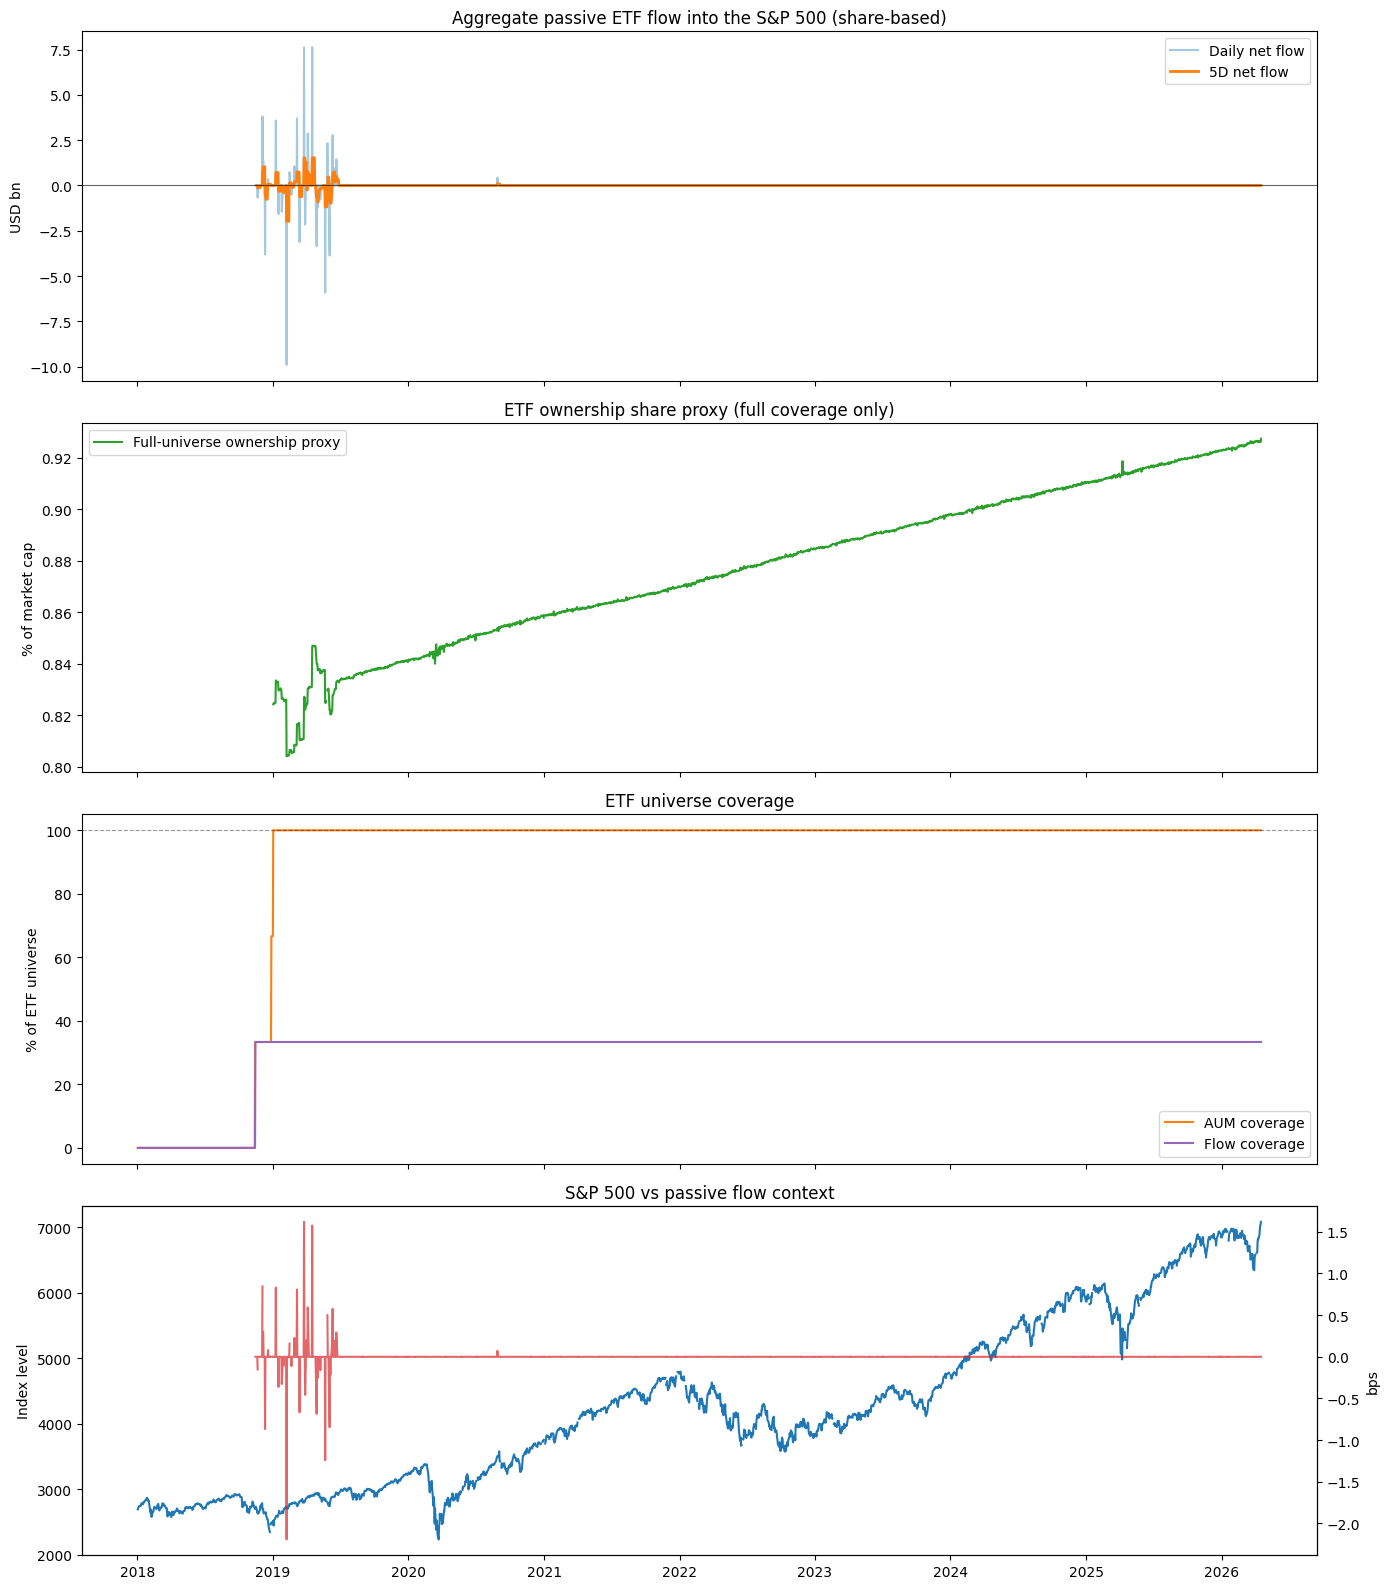

In [14]:
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 16), sharex=True)

axes[0].plot(aggregate_flow["date"], aggregate_flow["total_estimated_flow_usd"] / 1e9, label="Daily net flow", alpha=0.4)
axes[0].plot(aggregate_flow["date"], aggregate_flow["total_flow_5d_usd"] / 1e9, label="5D net flow", linewidth=2.0)
axes[0].axhline(0, color="black", linewidth=0.8, alpha=0.6)
axes[0].set_ylabel("USD bn")
axes[0].set_title("Aggregate passive ETF flow into the S&P 500 (share-based)")
axes[0].legend()

axes[1].plot(
    aggregate_flow["date"],
    aggregate_flow["etf_market_share_proxy"] * 100,
    color="tab:green",
    label="Full-universe ownership proxy",
)
axes[1].set_ylabel("% of market cap")
axes[1].set_title("ETF ownership share proxy (full coverage only)")
axes[1].legend()

axes[2].plot(
    aggregate_flow["date"],
    aggregate_flow["coverage_ratio"] * 100,
    color="tab:orange",
    label="AUM coverage",
)
axes[2].plot(
    aggregate_flow["date"],
    aggregate_flow["flow_coverage_ratio"] * 100,
    color="tab:purple",
    label="Flow coverage",
)
axes[2].axhline(100, color="black", linewidth=0.8, alpha=0.4, linestyle="--")
axes[2].set_ylabel("% of ETF universe")
axes[2].set_title("ETF universe coverage")
axes[2].legend()

axes[3].plot(aggregate_flow["date"], aggregate_flow["sp500_close"], color="tab:blue", label="S&P 500")
axes[3].set_ylabel("Index level")
axes[3].set_title("S&P 500 vs passive flow context")

second_axis = axes[3].twinx()
second_axis.plot(aggregate_flow["date"], aggregate_flow["passive_pressure_bps"], color="tab:red", alpha=0.7, label="Passive pressure (bps)")
second_axis.set_ylabel("bps")

plt.tight_layout()
plt.show()

In [15]:
correlation_summary = pd.DataFrame(
    {
        "same_day_corr": [aggregate_flow["total_estimated_flow_usd"].corr(aggregate_flow["sp500_return"])],
        "flow_leads_1d_corr": [aggregate_flow["total_estimated_flow_usd"].shift(1).corr(aggregate_flow["sp500_return"])],
        "price_leads_1d_corr": [aggregate_flow["total_estimated_flow_usd"].corr(aggregate_flow["sp500_return"].shift(1))],
    }
)

latest = aggregate_flow.dropna(subset=["total_estimated_flow_usd", "sp500_close"]).iloc[-1]
largest_divergence = aggregate_flow.assign(
    divergence_score=lambda frame: frame["passive_pressure_bps"].abs() * frame["sp500_return"].abs().rpow(-1)
).replace([np.inf, -np.inf], np.nan).dropna(subset=["divergence_score"]).nlargest(5, "divergence_score")

print("Latest snapshot")
print(
    pd.Series(
        {
            "date": latest["date"].date(),
            "daily_flow_usd_bn": round(latest["total_estimated_flow_usd"] / 1e9, 2),
            "passive_pressure_bps": round(latest["passive_pressure_bps"], 4),
            "etf_market_share_proxy_pct": round(latest["etf_market_share_proxy"] * 100, 2),
            "flow_coverage_pct": round(latest["flow_coverage_ratio"] * 100, 2),
            "behaviour_label": latest["behaviour_label"],
            "regime_label": latest["regime_label"],
        }
    )
)

print("\nFlow / return correlations")
display(correlation_summary)

print("Top divergence dates")
display(
    largest_divergence[[
        "date",
        "total_estimated_flow_usd",
        "passive_pressure_bps",
        "sp500_return",
        "behaviour_label",
        "regime_label",
    ]]
)

aggregate_artifact = _write_artifact(aggregate_flow, "aggregate_passive_flow")
etf_flow_artifact = _write_artifact(etf_dataset, "etf_flow_estimates")
print(f"Saved aggregate artifact to {aggregate_artifact}")
print(f"Saved ETF flow artifact to {etf_flow_artifact}")

Latest snapshot
date                          2026-04-17
daily_flow_usd_bn                    0.0
passive_pressure_bps                 0.0
etf_market_share_proxy_pct          0.93
flow_coverage_pct                  33.33
behaviour_label                    Mixed
regime_label                     Neutral
dtype: object

Flow / return correlations


,same_day_corr,flow_leads_1d_corr,price_leads_1d_corr
0,-0.001791,-0.015735,0.004548


Top divergence dates


,date,total_estimated_flow_usd,passive_pressure_bps,sp500_return,behaviour_label,regime_label


Saved aggregate artifact to ../artifacts/passive_flow_tracker/aggregate_passive_flow.parquet
Saved ETF flow artifact to ../artifacts/passive_flow_tracker/etf_flow_estimates.parquet
